Aquí tienes el script completo de Python estructurado exactamente igual al proceso detallado en tu cuaderno Jupyter.

El código está diseñado para recibir el nuevo archivo que contiene las variables meteorológicas junto con sus rezagos ya calculados. El script separa las variables de control y de salida (`año`, `semana_epi`, `casos_ln`), ejecuta el Análisis de Componentes Principales (**PCA**) sobre el bloque meteorológico, y genera los gráficos correspondientes (Varianza Explicada Acumulada y la matriz de *Loadings* o pesos) para que puedas evaluar la retención de información.

### Script de Reducción Dimensional (PCA) con Rezagos

```python


[INFO] Cargando datos desde:
C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\07_seleccion_entrenar_modelo\1_reduccion_dimensional\1_pca\2_data\1_raw_meteo_epi_con_y_sin_rezagos_escalados\2_datos_meteo_epi_con_rezagos_escalados.xlsx

--- Primeros registros del Dataset con Rezagos ---
             año  semana_epi  casos_ln   prec_ln  dias_lluvia_ln   temp_bc  \
fecha                                                                        
2021-03-28  2021          13 -1.667348 -2.114377       -2.365299  1.952723   
2021-04-04  2021          14 -2.254057 -1.030679       -0.657159  1.234977   
2021-04-11  2021          15 -2.254057  0.592161        0.420558  0.774582   
2021-04-18  2021          16 -2.254057  0.111296       -1.287582  1.180711   
2021-04-25  2021          17 -2.254057 -1.787021       -1.287582  1.183804   

            temp_max_bc  temp_min_bc  hum_esp_bc  hum_rel_bc  ...  \
fecha                                                         ...   
2021-03-

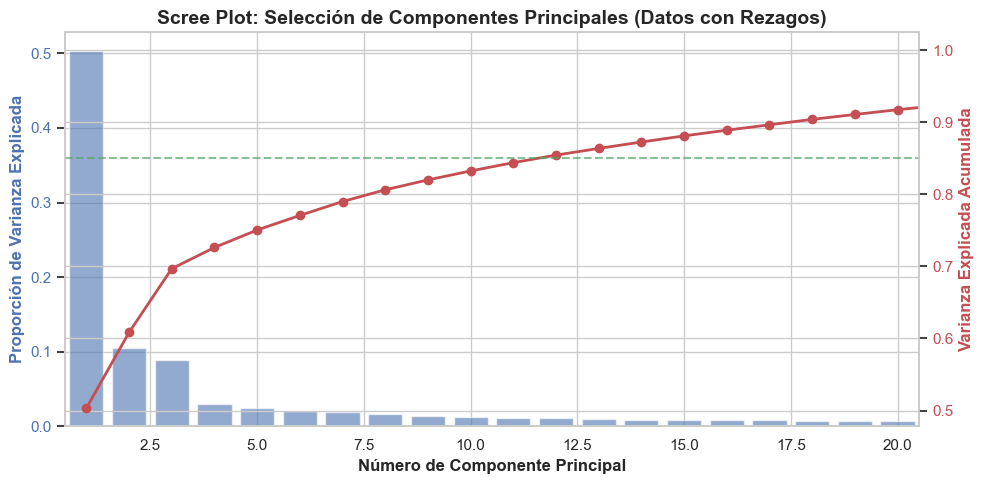


[INFO] Aplicando reducción final a 5 dimensiones...


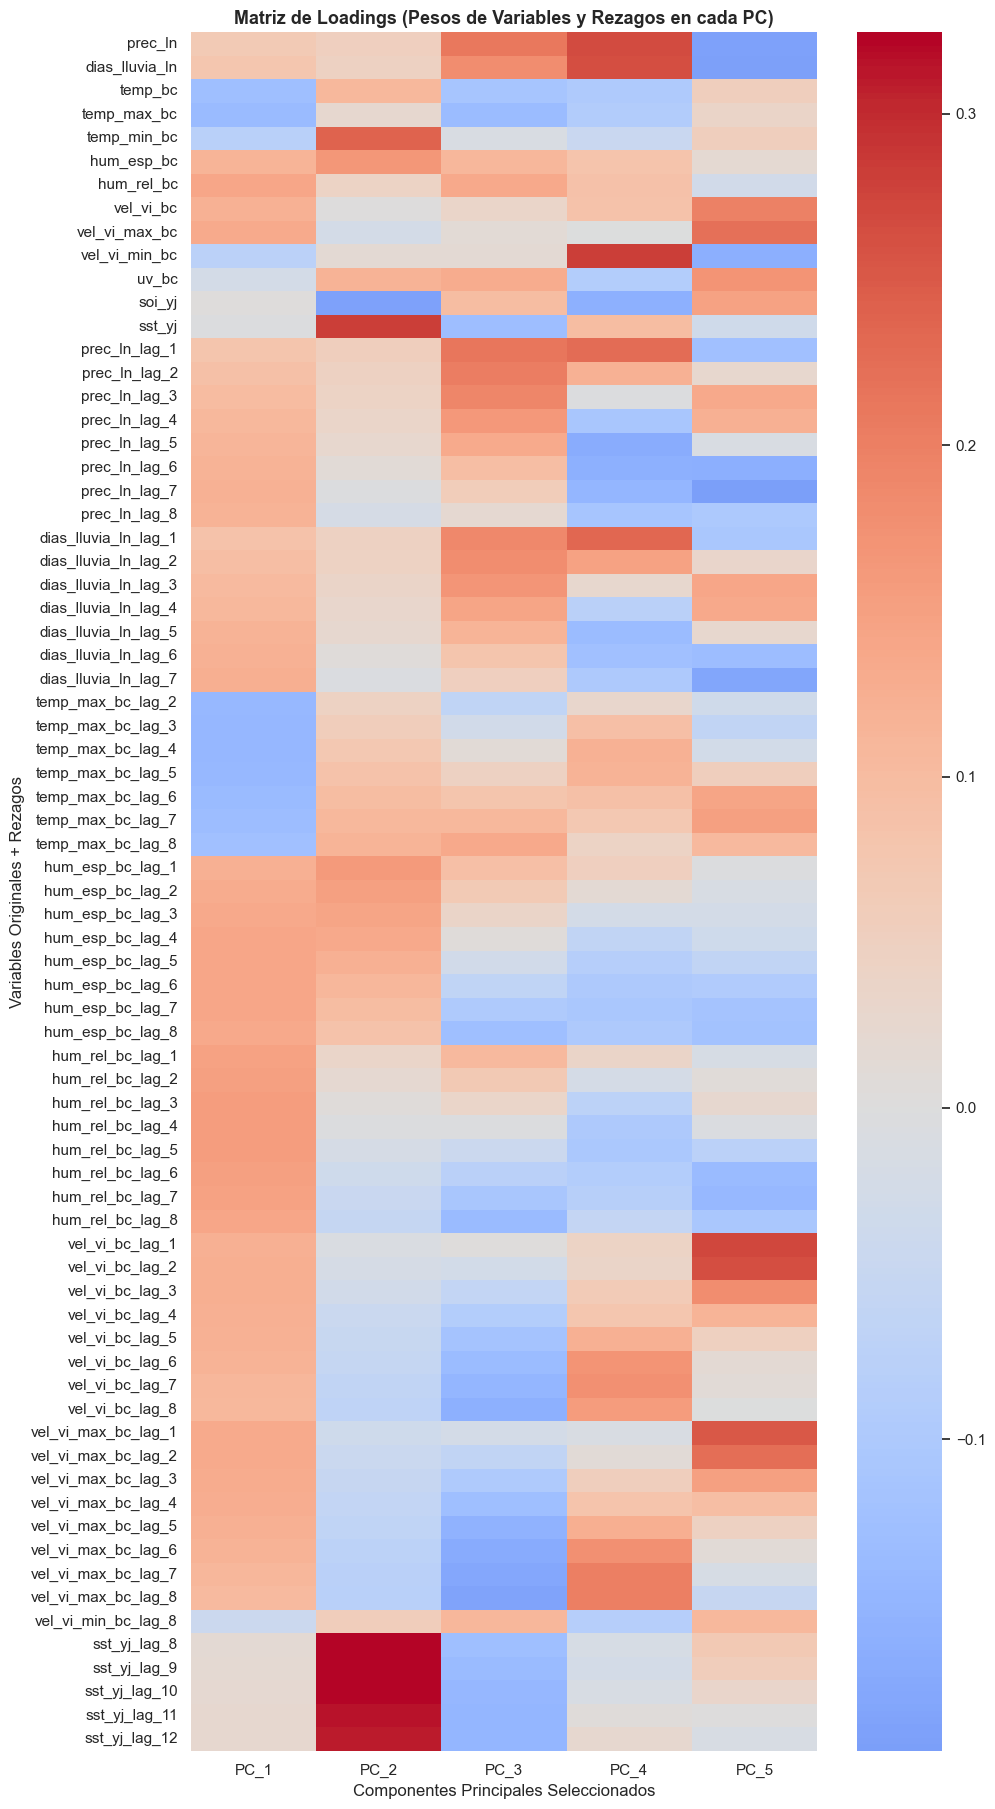


             EXPORTACIÓN DE DATOS EXITOSA              
Dataset generado correctamente en:
C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\07_seleccion_entrenar_modelo\1_reduccion_dimensional\1_pca\2_data\2_precesados\2_datos_meteo_epi_con_rezagos_escalados_con_pca_a_solo_cinco_dimensiones.xlsx
Dimensiones del archivo final: (249, 8)


In [2]:
# =============================================================================
# PASO 1: IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN
# =============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")

# =============================================================================
# PASO 2: CARGA DE DATOS (CON REZAGOS ESCALADOS)
# =============================================================================
# Ruta especificada por el usuario con el dataset que ya incluye los rezagos
ruta_datos = r"C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\07_seleccion_entrenar_modelo\1_reduccion_dimensional\1_pca\2_data\1_raw_meteo_epi_con_y_sin_rezagos_escalados\2_datos_meteo_epi_con_rezagos_escalados.xlsx"

print(f"[INFO] Cargando datos desde:\n{ruta_datos}")
df_original = pd.read_excel(ruta_datos, index_col=0, parse_dates=True)

print("\n--- Primeros registros del Dataset con Rezagos ---")
print(df_original.head())

# =============================================================================
# PASO 3: SEPARACIÓN DE VARIABLES (RESERVADAS VS METEOROLÓGICAS)
# =============================================================================
# Lista de variables de control y endógena que NO deben entrar al PCA
variables_reservadas = ['año', 'semana_epi', 'casos_ln']

# El resto de columnas (variables originales + rezagos) entran a la reducción dimensional
variables_pca = [col for col in df_original.columns if col not in variables_reservadas]

print(f"\n[INFO] Variables reservadas (quedan fuera del PCA): {variables_reservadas}")
print(f"[INFO] Total de variables/rezagos que entrarán al PCA: {len(variables_pca)}")

# Separación en DataFrames independientes
df_reservadas = df_original[variables_reservadas].copy()
df_meteo_con_rezagos = df_original[variables_pca].copy()

# =============================================================================
# PASO 4: AJUSTE DEL MODELO PCA
# =============================================================================
# Inicializamos el PCA sin restringir componentes para evaluar el espectro completo primero
pca = PCA()
pca.fit(df_meteo_con_rezagos)

# Cálculo de varianzas explicadas
varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

# Definimos un umbral estándar para la selección (ej. 85% o 90% de la varianza total)
UMBRAL_VARIANZA = 0.85
n_componentes_optimos = np.argmax(varianza_acumulada >= UMBRAL_VARIANZA) + 1

print("\n" + "="*60)
print("             RESUMEN DE VARIANZA EXPLICADA             ")
print("="*60)
for i, var in enumerate(varianza_explicada[:10]):  # Mostramos los primeros 10 por espacio
    print(f"Componente {i+1:2d}: Explicada = {var:.4f} | Acumulada = {varianza_acumulada[i]:.4f}")
print("-"*60)
print(f"[RECOMENDACIÓN] Para cubrir el {UMBRAL_VARIANZA*100}% de varianza, se necesitan {n_componentes_optimos} componentes.")
print("="*60)

# =============================================================================
# PASO 5: DIAGNÓSTICO GRÁFICO (CRITERIO SCREE PLOT)
# =============================================================================
fig, ax1 = plt.subplots(figsize=(10, 5))

# Gráfico de barras para la varianza individual
ax1.bar(range(1, len(varianza_explicada) + 1), varianza_explicada, alpha=0.6, color='b', label='Varianza Individual')
ax1.set_xlabel('Número de Componente Principal', fontsize=12, fontweight='bold')
ax1.set_ylabel('Proporción de Varianza Explicada', color='b', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_xlim(0.5, min(len(varianza_explicada) + 0.5, 20.5)) # Limitamos la vista a los primeros 20 para claridad

# Eje secundario para la varianza acumulada
ax2 = ax1.twinx()
ax2.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, color='r', marker='o', linewidth=2, label='Varianza Acumulada')
ax2.set_ylabel('Varianza Explicada Acumulada', color='r', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='r')

# Línea de corte del umbral
ax2.axhline(y=UMBRAL_VARIANZA, color='g', linestyle='--', alpha=0.7, label=f'Umbral ({UMBRAL_VARIANZA*100}%)')

plt.title('Scree Plot: Selección de Componentes Principales (Datos con Rezagos)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

# =============================================================================
# PASO 6: APLICACIÓN DEL RECORTE Y TRANSFORMACIÓN (EJEMPLO CON 5 DIMENSIONES)
# =============================================================================
# Mantenemos las 5 dimensiones solicitadas previamente para consistencia del pipeline
N_COMPONENTES_FIJOS = 5

print(f"\n[INFO] Aplicando reducción final a {N_COMPONENTES_FIJOS} dimensiones...")
pca_final = PCA(n_components=N_COMPONENTES_FIJOS)
componentes_transformados = pca_final.fit_transform(df_meteo_con_rezagos)

# Crear nombres para las nuevas columnas artificiales
columnas_pca = [f'PC_{i+1}' for i in range(N_COMPONENTES_FIJOS)]
df_pca_resultado = pd.DataFrame(componentes_transformados, columns=columnas_pca, index=df_original.index)

# =============================================================================
# PASO 7: MAPA DE CALOR DE LOADINGS (PESOS DE LAS VARIABLES)
# =============================================================================
# Extraemos los pesos que correlacionan las variables/rezagos originales con los PCs
loadings = pd.DataFrame(
    pca_final.components_.T, 
    columns=columnas_pca, 
    index=variables_pca
)

# Graficamos el mapa de calor (mostrando las variables más influyentes si son demasiadas)
plt.figsize=(12, 10)
plt.figure(figsize=(10, max(6, len(variables_pca) * 0.25)))
sns.heatmap(loadings, annot=False, cmap='coolwarm', center=0, cbar=True)
plt.title('Matriz de Loadings (Pesos de Variables y Rezagos en cada PC)', fontsize=13, fontweight='bold')
plt.ylabel('Variables Originales + Rezagos')
plt.xlabel('Componentes Principales Seleccionados')
plt.tight_layout()
plt.show()

# =============================================================================
# PASO 8: RECONSTRUCCIÓN DEL DATASET FINAL Y EXPORTACIÓN
# =============================================================================
# Concatenamos de nuevo las columnas reservadas con las nuevas dimensiones calculadas
df_resultado_final = pd.concat([df_reservadas, df_pca_resultado], axis=1)

# Estructurar la ruta de guardado
carpeta_destino = r"C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\07_seleccion_entrenar_modelo\1_reduccion_dimensional\1_pca\2_data\2_precesados"
nuevo_nombre = "2_datos_meteo_epi_con_rezagos_escalados_con_pca_a_solo_cinco_dimensiones.xlsx"
ruta_salida_final = os.path.join(carpeta_destino, nuevo_nombre)

# Crear el directorio si no existe
if not os.path.exists(carpeta_destino):
    os.makedirs(carpeta_destino)

# Guardar en Excel
df_resultado_final.to_excel(ruta_salida_final)

print("\n" + "="*60)
print("             EXPORTACIÓN DE DATOS EXITOSA              ")
print("="*60)
print(f"Dataset generado correctamente en:\n{ruta_salida_final}")
print(f"Dimensiones del archivo final: {df_resultado_final.shape}")
print("="*60)



```

### ¿Qué cambia ahora que se incluyen rezagos?

1. **Dimensión de la matriz de entrada (`loadings`):** El mapa de calor del **Paso 7** será considerablemente más largo verticalmente. Esto se debe a que cada variable original (ej. `temp_bc`) ahora viene acompañada por sus versiones retrasadas en el tiempo (`temp_bc_rezago_1`, etc.). El PCA se encargará de encontrar las combinaciones lineales óptimas de todo este conjunto extendido.
2. **Interpretación de los Componentes (PCs):** Al revisar el gráfico de *Loadings*, notarás si un componente principal se está especializando en capturar dinámicas sincrónicas (variables en el tiempo actual) o dinámicas inerciales (las variables rezagadas).